# 03 — Model Evaluation

Evaluación avanzada del modelo de churn con enfoque técnico y de negocio.

## Objetivos
- Cargar el pipeline entrenado.
- Evaluar Accuracy, Precision, Recall, F1 y ROC-AUC.
- Analizar matriz de confusión.
- Construir curvas ROC y Precision-Recall.
- Comparar distintos umbrales de clasificación.
- Analizar falsos positivos y falsos negativos.
- Interpretar la importancia de variables.
- Guardar métricas y gráficos en `reports/`.


## 1. Configuración del entorno

Ejecute este notebook desde la raíz del repositorio. En Google Colab:

```python
!git clone <URL_DEL_REPOSITORIO>
%cd customer-intelligence-ml-platform
```


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    for candidate in [PROJECT_ROOT, *PROJECT_ROOT.parents]:
        if (candidate / "src").exists():
            PROJECT_ROOT = candidate
            break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"Project root: {PROJECT_ROOT}")


Project root: /workspaces/customer-intelligence-ml-platform/entregable_D3_16_repositorio_final_curso_1


## 2. Importación de librerías


In [2]:
import json
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, average_precision_score, classification_report, confusion_matrix, f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import train_test_split
from src.data import load_customer_data
from src.features import split_features_target
from src.models.evaluation import evaluate_binary_classifier
from src.utils import get_project_path, get_logger
logger = get_logger("notebook.model_evaluation")


## 3. Carga de datos y modelo


In [3]:
DATA_PATH = get_project_path("data", "raw", "customer_churn.csv")
MODEL_PATH = get_project_path("artifacts", "models", "selected_churn_pipeline.joblib")
df = load_customer_data(DATA_PATH)
if not MODEL_PATH.exists():
    raise FileNotFoundError("Ejecute primero 02_model_development.ipynb")
pipeline = joblib.load(MODEL_PATH)
print(df.shape, MODEL_PATH)


2026-09-30 03:29:17,756 | INFO | src.data.data_loader | Loaded customer dataset with shape (1000, 21)


(1000, 21) /workspaces/customer-intelligence-ml-platform/entregable_D3_16_repositorio_final_curso_1/artifacts/models/selected_churn_pipeline.joblib


## 4. Reconstrucción del conjunto de prueba


In [4]:
X, y = split_features_target(df)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(len(X_train), len(X_test), y_test.mean())


800 200 0.24


## 5. Predicciones y probabilidades


In [5]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]
evaluation_df = X_test.copy()
evaluation_df["actual_churn"] = y_test.values
evaluation_df["predicted_churn"] = y_pred
evaluation_df["churn_probability"] = y_proba
evaluation_df.head()


,age,tenure_months,monthly_fee,total_spent,support_calls,complaints,last_payment_delay,digital_usage_score,marketing_score,preferred_contact_hour,...,region,customer_segment,contract_type,internet_service,tv_service,streaming_service,payment_method,actual_churn,predicted_churn,churn_probability
295,48.0,85,77.44,6317.44,2,1,3,56.6,59.6,8,...,Norte,Familia,Mensual,DSL,No,No,Transferencia,0,0,0.432468
130,44.0,17,44.55,689.52,0,1,2,60.8,74.2,9,...,Centro,Masivo,Bianual,Sin internet,No,No,Tarjeta,0,0,0.217864
491,61.0,28,119.15,2630.61,2,0,2,71.2,55.2,12,...,Sur,Joven digital,Anual,Fibra,No,Sí,Débito automático,0,0,0.363604
366,42.0,20,120.50,2384.61,1,0,5,57.2,71.8,19,...,Lima,Premium,Mensual,DSL,No,Sí,Tarjeta,0,1,0.525067
732,41.0,39,99.27,3884.07,3,0,3,76.5,66.3,9,...,Lima,Familia,Mensual,DSL,No,Sí,Tarjeta,0,1,0.588257


## 6. Métricas principales


In [6]:
metrics = evaluate_binary_classifier(y_test, y_pred, y_proba)
pd.Series(metrics, name="value").to_frame()


,value
accuracy,0.730000
precision,0.448276
recall,0.541667
f1,0.490566
roc_auc,0.737664


In [7]:
print(classification_report(y_test, y_pred, target_names=["No churn", "Churn"], digits=4))


              precision    recall  f1-score   support

    No churn     0.8451    0.7895    0.8163       152
       Churn     0.4483    0.5417    0.4906        48

    accuracy                         0.7300       200
   macro avg     0.6467    0.6656    0.6534       200
weighted avg     0.7498    0.7300    0.7381       200



### Interpretación
- **Precision:** de los clientes predichos como churn, cuántos realmente cancelan.
- **Recall:** de los clientes que realmente cancelan, cuántos fueron detectados.
- **F1-score:** equilibrio entre Precision y Recall.
- **ROC-AUC:** capacidad de ordenar correctamente clientes de mayor y menor riesgo.


## 7. Matriz de confusión


In [8]:
cm = confusion_matrix(y_test, y_pred)
cm


array([[120,  32],
       [ 22,  26]])

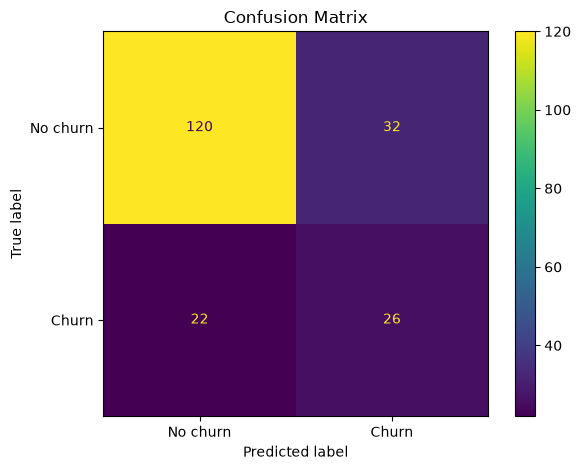

In [9]:
display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No churn", "Churn"])
display_cm.plot(values_format="d")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


In [10]:
tn, fp, fn, tp = cm.ravel()
pd.DataFrame({"metric":["TN","FP","FN","TP"],"count":[tn,fp,fn,tp]})


,metric,count
0,TN,120
1,FP,32
2,FN,22
3,TP,26


### Discusión de negocio
- **Falso positivo:** campaña innecesaria.
- **Falso negativo:** cliente perdido sin intervención.
En retención, normalmente el falso negativo tiene mayor costo.


## 8. Curva ROC


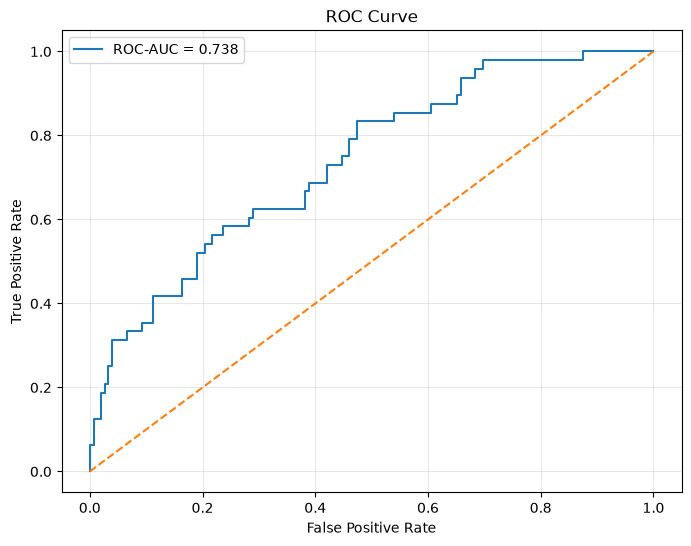

In [11]:
fpr, tpr, roc_thresholds = roc_curve(y_test, y_proba)
roc_auc = roc_auc_score(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC Curve"); plt.legend(); plt.grid(alpha=.3); plt.show()


## 9. Curva Precision-Recall


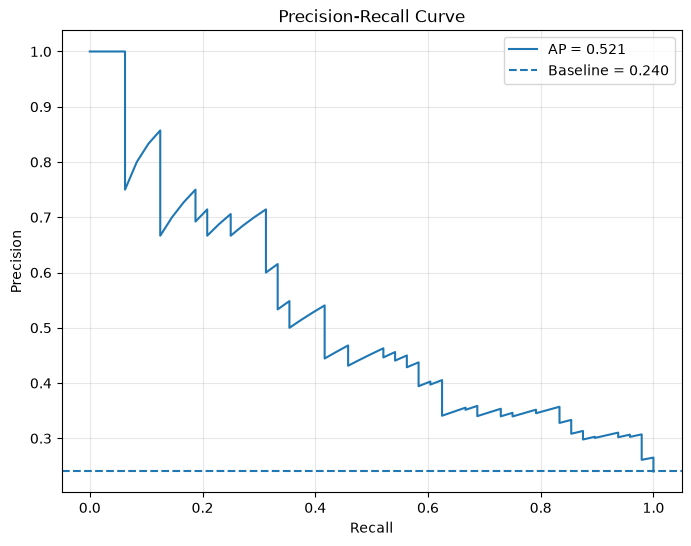

In [12]:
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, y_proba)
average_precision = average_precision_score(y_test, y_proba)
plt.figure(figsize=(8,6))
plt.plot(recall_curve, precision_curve, label=f"AP = {average_precision:.3f}")
plt.axhline(y=y_test.mean(), linestyle="--", label=f"Baseline = {y_test.mean():.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall Curve"); plt.legend(); plt.grid(alpha=.3); plt.show()


## 10. Evaluación de umbrales


In [13]:
thresholds = np.arange(0.10, 0.91, 0.05)
rows=[]
for threshold in thresholds:
    pred=(y_proba>=threshold).astype(int)
    rows.append({"threshold":threshold,"accuracy":accuracy_score(y_test,pred),"precision":precision_score(y_test,pred,zero_division=0),"recall":recall_score(y_test,pred,zero_division=0),"f1":f1_score(y_test,pred,zero_division=0),"predicted_churn_rate":pred.mean()})
threshold_df=pd.DataFrame(rows)
threshold_df


,threshold,accuracy,precision,recall,f1,predicted_churn_rate
0,0.10,0.250,0.242424,1.000000,0.390244,0.990
1,0.15,0.280,0.250000,1.000000,0.400000,0.960
2,0.20,0.335,0.262570,0.979167,0.414097,0.895
3,0.25,0.460,0.302632,0.958333,0.460000,0.760
4,0.30,0.490,0.304348,0.875000,0.451613,0.690
5,0.35,0.555,0.333333,0.854167,0.479532,0.615
6,0.40,0.610,0.346939,0.708333,0.465753,0.490
7,0.45,0.685,0.397260,0.604167,0.479339,0.365
8,0.50,0.730,0.448276,0.541667,0.490566,0.290
9,0.55,0.765,0.514286,0.375000,0.433735,0.175


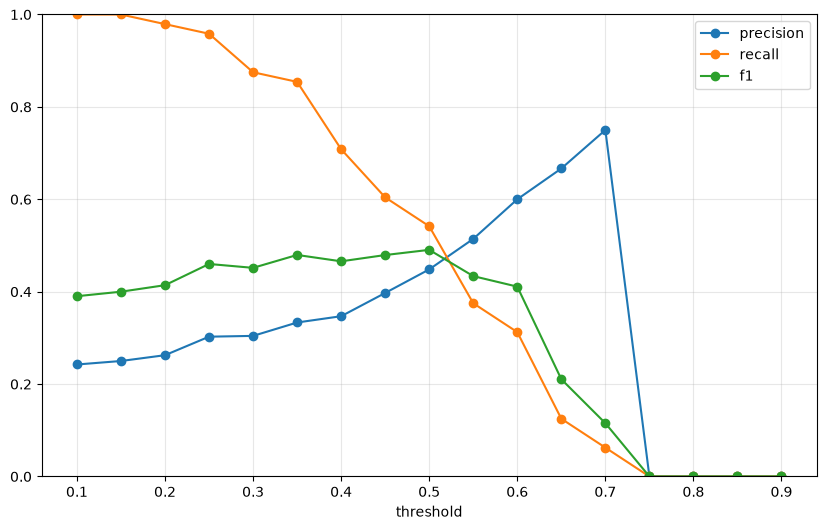

In [14]:
ax=threshold_df.plot(x="threshold",y=["precision","recall","f1"],figsize=(10,6),marker="o")
ax.set_ylim(0,1); ax.grid(alpha=.3); plt.show()


## 11. Selección de umbral por criterio


In [15]:
best_f1_row = threshold_df.loc[threshold_df["f1"].idxmax()]
best_recall_row = threshold_df.query("precision >= 0.40").sort_values("recall",ascending=False).head(1)
display(best_f1_row.to_frame().T)
display(best_recall_row)


,threshold,accuracy,precision,recall,f1,predicted_churn_rate
8,0.5,0.73,0.448276,0.541667,0.490566,0.29


,threshold,accuracy,precision,recall,f1,predicted_churn_rate
8,0.5,0.73,0.448276,0.541667,0.490566,0.29


### Regla pedagógica sugerida
Use umbral bajo si perder clientes es muy costoso; umbral alto si la campaña es costosa. Seleccione con costos y capacidad operativa.


## 12. Simulación simple de costos


In [16]:
RETENTION_CAMPAIGN_COST=25
FALSE_NEGATIVE_COST=300
TRUE_POSITIVE_BENEFIT=180
cost_rows=[]
for threshold in thresholds:
    pred=(y_proba>=threshold).astype(int)
    tn2,fp2,fn2,tp2=confusion_matrix(y_test,pred).ravel()
    net=tp2*TRUE_POSITIVE_BENEFIT-(tp2+fp2)*RETENTION_CAMPAIGN_COST-fn2*FALSE_NEGATIVE_COST
    cost_rows.append({"threshold":threshold,"tp":tp2,"fp":fp2,"fn":fn2,"net_value":net})
cost_df=pd.DataFrame(cost_rows)
cost_df.sort_values("net_value",ascending=False).head()


,threshold,tp,fp,fn,net_value
3,0.25,46,106,2,3880
1,0.15,48,144,0,3840
0,0.10,48,150,0,3690
2,0.20,47,132,1,3685
4,0.30,42,96,6,2310


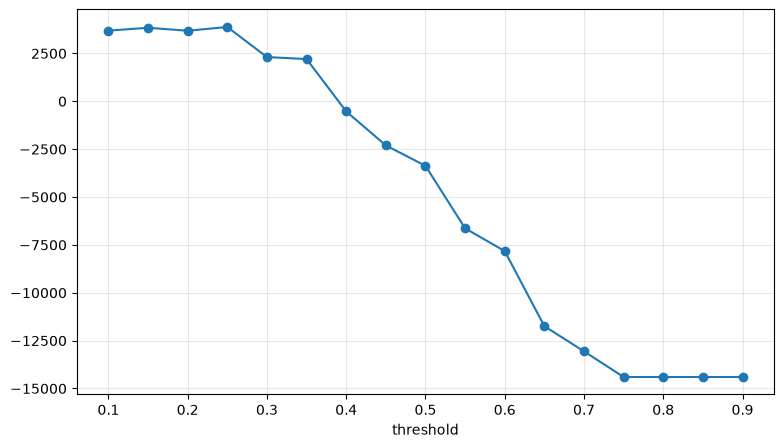

In [17]:
ax=cost_df.plot(x="threshold",y="net_value",figsize=(9,5),marker="o",legend=False)
ax.grid(alpha=.3); plt.show()


## 13. Análisis de falsos positivos


In [18]:
false_positives=evaluation_df.query("actual_churn == 0 and predicted_churn == 1").sort_values("churn_probability",ascending=False)
print(len(false_positives))
false_positives.head(10)


32


,age,tenure_months,monthly_fee,total_spent,support_calls,complaints,last_payment_delay,digital_usage_score,marketing_score,preferred_contact_hour,...,region,customer_segment,contract_type,internet_service,tv_service,streaming_service,payment_method,actual_churn,predicted_churn,churn_probability
636,20.0,19,86.83,1537.45,2,2,6,59.2,70.5,19,...,Centro,Familia,Mensual,DSL,Sí,No,Tarjeta,0,1,0.700613
740,41.0,26,84.06,2260.45,4,0,1,51.8,46.0,13,...,Sur,Familia,Mensual,DSL,Sí,No,Débito automático,0,1,0.669295
656,53.0,48,107.65,4766.20,3,2,8,57.7,89.3,14,...,NaN,Masivo,Mensual,DSL,Sí,Sí,Débito automático,0,1,0.667263
278,39.0,17,113.87,1867.03,2,1,12,60.6,61.9,13,...,Oriente,Masivo,Mensual,Fibra,No,Sí,Tarjeta,0,1,0.632540
635,54.0,6,102.61,557.68,3,0,7,100.0,67.0,17,...,Sur,Joven digital,Mensual,Fibra,No,No,Débito automático,0,1,0.628350
204,18.0,15,116.51,1416.97,3,1,5,95.1,66.9,20,...,Lima,Masivo,Mensual,Fibra,Sí,Sí,Efectivo,0,1,0.625415
253,37.0,9,85.11,807.85,3,0,7,79.1,74.5,18,...,Lima,Masivo,Mensual,Fibra,No,No,Transferencia,0,1,0.606885
788,46.0,50,128.99,6624.98,3,1,4,52.3,60.0,9,...,Oriente,Masivo,Mensual,Fibra,Sí,Sí,Transferencia,0,1,0.604531
406,18.0,39,89.76,3489.18,2,2,10,68.1,51.7,11,...,Lima,Masivo,Mensual,DSL,No,No,Débito automático,0,1,0.604391
974,39.0,49,141.05,5932.03,2,2,14,60.0,61.1,12,...,Lima,Premium,Mensual,Fibra,Sí,No,Tarjeta,0,1,0.603635


## 14. Análisis de falsos negativos


In [19]:
false_negatives=evaluation_df.query("actual_churn == 1 and predicted_churn == 0").sort_values("churn_probability")
print(len(false_negatives))
false_negatives.head(10)


22


,age,tenure_months,monthly_fee,total_spent,support_calls,complaints,last_payment_delay,digital_usage_score,marketing_score,preferred_contact_hour,...,region,customer_segment,contract_type,internet_service,tv_service,streaming_service,payment_method,actual_churn,predicted_churn,churn_probability
584,29.0,42,90.62,3883.47,0,0,2,57.7,54.3,17,...,Lima,Masivo,Bianual,DSL,No,Sí,Débito automático,1,0,0.197285
917,18.0,6,98.92,631.94,1,0,3,54.7,67.8,20,...,Centro,Masivo,Bianual,Fibra,Sí,Sí,Transferencia,1,0,0.241737
767,31.0,40,78.95,3090.34,4,1,6,75.3,45.4,15,...,Lima,Joven digital,Bianual,DSL,No,No,Transferencia,1,0,0.256641
268,28.0,26,128.13,2774.70,1,0,15,NaN,50.8,20,...,Lima,Joven digital,Anual,Fibra,No,Sí,Tarjeta,1,0,0.275951
889,36.0,24,170.95,4650.68,0,0,1,62.3,75.6,12,...,Oriente,Premium,Anual,Fibra,Sí,Sí,Transferencia,1,0,0.283024
586,33.0,14,72.87,NaN,0,0,2,76.1,93.1,11,...,Oriente,Joven digital,Bianual,DSL,Sí,No,Efectivo,1,0,0.289176
925,23.0,15,83.22,1350.88,1,1,9,51.2,88.0,19,...,Lima,Masivo,Anual,Fibra,No,No,Débito automático,1,0,0.318609
20,42.0,73,38.13,2420.31,3,1,9,71.5,65.7,19,...,Lima,Masivo,Mensual,NaN,No,No,Efectivo,1,0,0.350072
213,21.0,30,75.68,2144.67,0,1,7,49.6,65.9,20,...,Lima,Familia,Anual,DSL,No,Sí,Tarjeta,1,0,0.364790
437,30.0,32,125.79,3466.90,2,0,16,49.2,56.8,20,...,Norte,Premium,Anual,Fibra,No,No,Transferencia,1,0,0.364817


## 15. Comparación de perfiles


In [20]:
profile_columns=["tenure_months","monthly_fee","support_calls","complaints","last_payment_delay","digital_usage_score","marketing_score"]
profile_comparison=pd.DataFrame({"true_positive":evaluation_df.query("actual_churn == 1 and predicted_churn == 1")[profile_columns].mean(),"false_negative":false_negatives[profile_columns].mean(),"false_positive":false_positives[profile_columns].mean(),"true_negative":evaluation_df.query("actual_churn == 0 and predicted_churn == 0")[profile_columns].mean()})
profile_comparison


,true_positive,false_negative,false_positive,true_negative
tenure_months,21.346154,29.409091,30.500000,42.216667
monthly_fee,101.557692,93.977273,96.873750,105.107167
support_calls,2.346154,1.454545,1.937500,1.375000
complaints,1.115385,0.590909,0.906250,0.466667
last_payment_delay,5.192308,8.000000,5.187500,5.741667
digital_usage_score,72.073913,64.995238,69.084375,70.487500
marketing_score,64.220833,67.822727,64.962500,67.272807


## 16. Importancia de variables


In [21]:
classifier=pipeline.named_steps["classifier"]
preprocessor=pipeline.named_steps["preprocessor"]
feature_names=preprocessor.get_feature_names_out()
importance_df=None
if hasattr(classifier,"feature_importances_"):
    importance_df=pd.DataFrame({"feature":feature_names,"importance":classifier.feature_importances_}).sort_values("importance",ascending=False)
elif hasattr(classifier,"coef_"):
    importance_df=pd.DataFrame({"feature":feature_names,"coefficient":classifier.coef_[0]}).assign(absolute_importance=lambda x:x["coefficient"].abs()).sort_values("absolute_importance",ascending=False)
importance_df.head(15)


,feature,importance
1,tenure_months,0.092806
3,total_spent,0.090394
8,marketing_score,0.073740
7,digital_usage_score,0.073051
2,monthly_fee,0.072909
0,age,0.062987
6,last_payment_delay,0.060547
23,contract_type_Mensual,0.054750
4,support_calls,0.054392
9,preferred_contact_hour,0.053005


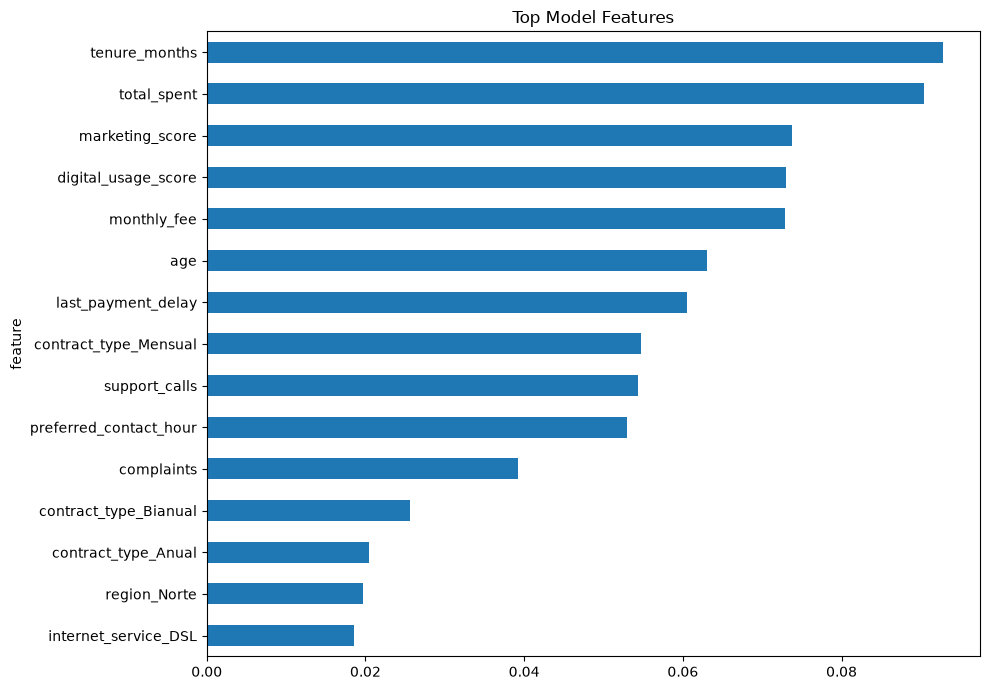

In [22]:
if "importance" in importance_df.columns:
    plot_data=importance_df.head(15).sort_values("importance"); x_col="importance"
else:
    plot_data=importance_df.head(15).sort_values("absolute_importance"); x_col="absolute_importance"
plot_data.plot(x="feature",y=x_col,kind="barh",figsize=(10,7),legend=False)
plt.title("Top Model Features"); plt.tight_layout(); plt.show()


## 17. Guardado de métricas y reportes


In [23]:
METRICS_OUTPUT=get_project_path("reports","metrics","advanced_evaluation.json",create_parent=True)
THRESHOLD_OUTPUT=get_project_path("reports","metrics","threshold_analysis.csv",create_parent=True)
ERRORS_OUTPUT=get_project_path("reports","predictions","evaluation_errors.csv",create_parent=True)
payload={"base_metrics":metrics,"roc_auc":roc_auc,"average_precision":average_precision,"confusion_matrix":{"tn":int(tn),"fp":int(fp),"fn":int(fn),"tp":int(tp)},"best_threshold_by_f1":float(best_f1_row["threshold"]),"best_f1":float(best_f1_row["f1"])}
METRICS_OUTPUT.write_text(json.dumps(payload,ensure_ascii=False,indent=2),encoding="utf-8")
threshold_df.to_csv(THRESHOLD_OUTPUT,index=False)
pd.concat([false_positives.assign(error_type="false_positive"),false_negatives.assign(error_type="false_negative")]).to_csv(ERRORS_OUTPUT,index=False)
print(METRICS_OUTPUT, THRESHOLD_OUTPUT, ERRORS_OUTPUT)


/workspaces/customer-intelligence-ml-platform/entregable_D3_16_repositorio_final_curso_1/reports/metrics/advanced_evaluation.json /workspaces/customer-intelligence-ml-platform/entregable_D3_16_repositorio_final_curso_1/reports/metrics/threshold_analysis.csv /workspaces/customer-intelligence-ml-platform/entregable_D3_16_repositorio_final_curso_1/reports/predictions/evaluation_errors.csv


## 18. Exportación de gráficos


In [24]:
FIGURES_DIR=get_project_path("artifacts","figures","placeholder.txt",create_parent=True).parent
plt.figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC Curve"); plt.legend(); plt.tight_layout()
plt.savefig(FIGURES_DIR/"roc_curve.png",dpi=150)
plt.close()
print(FIGURES_DIR/"roc_curve.png")


/workspaces/customer-intelligence-ml-platform/entregable_D3_16_repositorio_final_curso_1/artifacts/figures/roc_curve.png


## 19. Preguntas para estudiantes
1. ¿Por qué 0.50 no siempre es óptimo?
2. ¿Qué error es más costoso para NovaTel?
3. ¿Qué métrica usaría para priorizar clientes?
4. ¿Cómo cambia la decisión si la campaña cuesta S/100?
5. ¿Qué perfiles predominan entre falsos negativos?
6. ¿Por qué importancia no implica causalidad?


## 20. Checklist de cierre
- [ ] Métricas base calculadas.
- [ ] Matriz de confusión interpretada.
- [ ] Curvas ROC y PR creadas.
- [ ] Umbrales evaluados.
- [ ] Costos simulados.
- [ ] FP y FN analizados.
- [ ] Importancia revisada.
- [ ] Reportes guardados.


## Resultado esperado
La evaluación se convierte en una decisión reproducible de negocio, no solo en una lectura de Accuracy.
